In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft
import pandas as pd
from scipy import signal

# 7章演習問題　1/2

## (1) $h(n)=\frac{1}{N}[1, 1, \cdots, 1]$

### (a) 伝達関数

\begin{align*}
H(z) &= \frac{1}{N}\Sigma_{n=0}^{N-1}z^{-n}\\
&= \frac{1}{N}\frac{1-z^{-N}}{1-z^{-1}}, \quad z^{-1}\neq 1
\end{align*}

### (b)周波数応答

\begin{align*}
H(e^{j\omega}) &= \frac{1}{N}\frac{1 - e^{-j\omega N}}{1 - e^{-j\omega}}\\
&= \frac{1}{N}\frac{(e^{j\frac{\omega N}{2}} - e^{-j\frac{\omega N}{2}})e^{-j\frac{\omega N}{2}}}
{(e^{-j\frac{\omega}{2}} - e^{-j\frac{\omega}{2}})e^{-j\frac{\omega}{2}}}\\
&= \frac{1}{N}\frac{\sin \frac{\omega N}{2}}{\sin \frac{\omega}{2}}e^{-j\omega \frac{N-1}{2}}.\\
|H(e^{j\omega})| &= \frac{1}{N} \left| \frac{\sin \frac{\omega N}{2}}{\sin \frac{\omega}{2}} \right|,\\
\angle H(e^{j\omega}) &= -\frac{N-1}{2}\omega.\\
\end{align*}

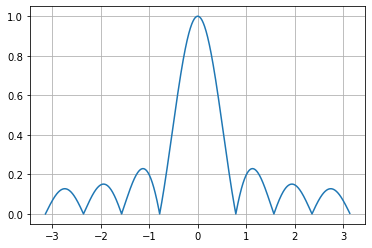

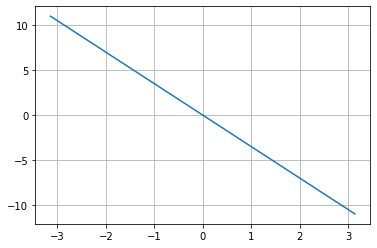

In [20]:
h = np.array([1, 1, 1, 1, 1, 1, 1, 1]) / 8.0
omega = np.linspace(-np.pi, np.pi, 1024, endpoint=False)
absH = np.zeros_like(omega)
argH = np.zeros_like(omega)

for k in range(len(omega)):
    if omega[k] != 0:
        absH[k] = np.abs(np.sin(omega[k] * 8.0 / 2.0) / np.sin(omega[k] / 2.0)) / 8.0
    else:
        absH[k] = 1.0
    argH[k] = -7.0 / 2.0 * omega[k]


fig1 = plt.figure()
ax1 = fig1.add_subplot(1, 1, 1)
ax1.plot(omega, absH)
ax1.grid()

fig2 = plt.figure()
ax2 = fig2.add_subplot(1, 1, 1)
ax2.plot(omega, argH)
ax2.grid()

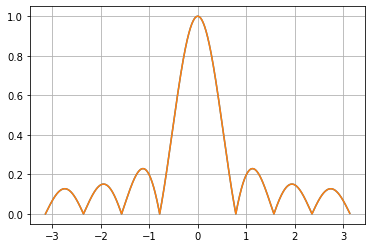

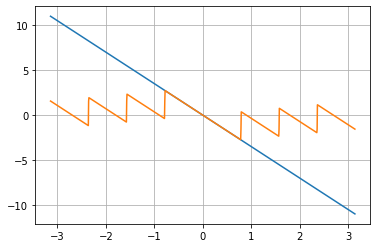

In [19]:
h = np.array([1, 1, 1, 1, 1, 1, 1, 1]) / 8.0
_, H2 = signal.freqz(h, 1.0, omega)
absH2 = np.abs(H2)
argH2 = np.angle(H2)

fig1 = plt.figure()
ax1 = fig1.add_subplot(1, 1, 1)
ax1.plot(omega, absH)
ax1.plot(omega, absH2)
ax1.grid()

fig2 = plt.figure()
ax2 = fig2.add_subplot(1, 1, 1)
ax2.plot(omega, argH)
ax2.plot(omega, argH2)
ax2.grid()

(c) 極零配置

\begin{align*}
H(z) &= \frac{1}{N}\frac{1-z^{-N}}{1-z^{-1}}\\
&= \frac{1}{N}\frac{z^{N}-1}{z^{N-1}(z-1)}\\
\end{align*}

分子多項式の根は$z_k=e^{j\frac{2\pi}{N} k}, k=0,1,2,\ldots,N-1$，
分母多項式の根は$p_0=1$，および$p_k=0, k=1,2,\ldots,N-1$で，$z_0=1$と$p_0=1$は相殺されるため零点と極に含めない．
したがって，零点は$z_k=e^{j\frac{2\pi}{N} k}, \quad k=1, 2, \ldots , N-1$，極は$p_k=0, k=1, 2, \ldots, N-1$

零点に対応する周波数で振幅は０になっている．

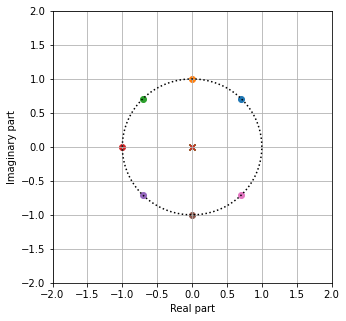

In [28]:
N = 8
plt.figure(figsize=(5, 5))
for k in [i for i in range(1, N)]:
    plt.scatter(np.cos(2.0 * np.pi * k / N), np.sin(2.0 * np.pi * k / N),
                label="zeros, k="+str(k), marker="o")
    
for k in [i for i in range(1, N)]:
    plt.scatter(0.0, 0.0,
                label="poles, k="+str(k), marker="x")

theta = np.linspace(0, 2*np.pi, 360)
plt.plot(np.cos(theta), np.sin(theta), c="black", linestyle="dotted")
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.xlabel("Real part")
plt.ylabel("Imaginary part")
#plt.legend()
plt.grid()
plt.show()

## (2) $y(n) = \rho e^{j\phi}y(n-1) + x(n)$

### (a) 単位インパルス応答 

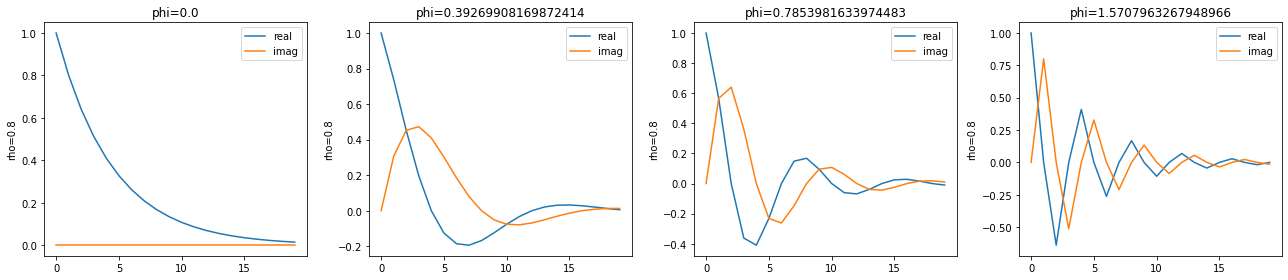

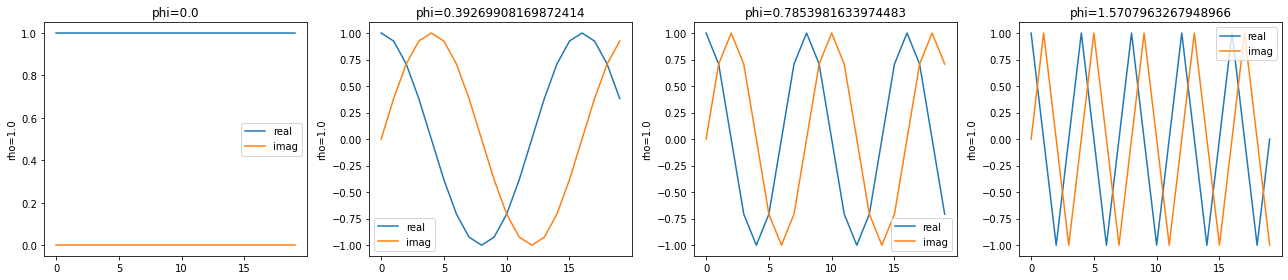

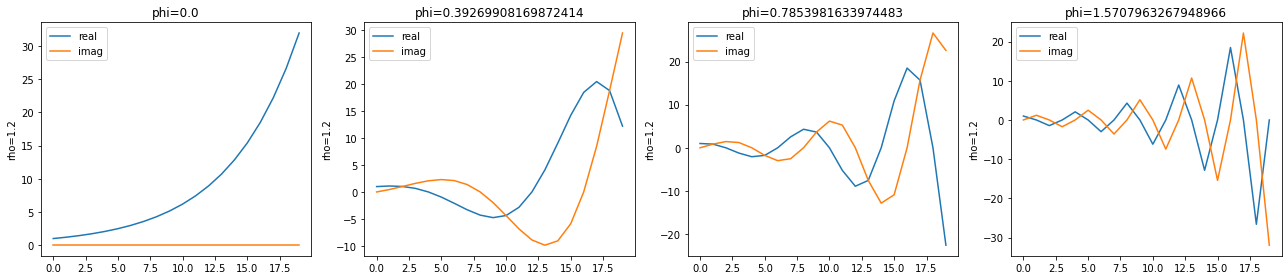

In [52]:
def unit_impluse(n):
    if n == 0:
        delta = 1
    else:
        delta = 0
    return delta


n_samples = 20
for rho in [0.8, 1.0, 1.2]:
    plt.figure(figsize=(18, 4))
    i = 0
    for phi in [0.0, np.pi/8.0, np.pi/4.0, np.pi/2.0]:
        y = np.zeros(n_samples, dtype=np.complex128)
        for n in range(n_samples):
            y[n] = rho * np.exp(1.0j * phi) * y[n-1] + unit_impluse(n)
        i+=1
        plt.subplot(1, 4, i)
        plt.title("phi="+str(phi))
        plt.ylabel("rho="+str(rho))
        plt.plot(range(n_samples), y.real, label="real")
        plt.plot(range(n_samples), y.imag, label="imag")
        plt.legend()
    plt.tight_layout()
    plt.show()

### (b) 伝達関数と周波数応答

\begin{align*}
H(z) &= \frac{1}{1-\rho e^{j\phi}z^{-1}},\\
H(e^{j\omega}) &= \frac{1}{1-\rho e^{j\phi}e^{-j\omega}}\\
&= \frac{1}{1-\rho e^{-j(\omega - \phi)}}
\end{align*}

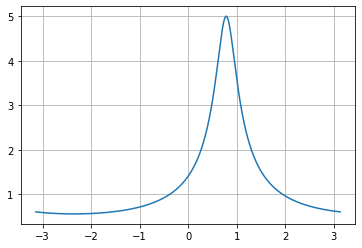

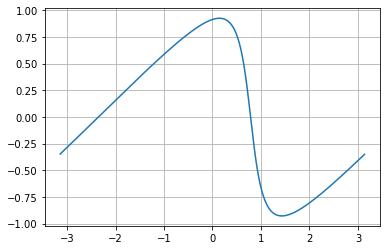

In [72]:
omega = np.linspace(-np.pi, np.pi, 1024, endpoint=False)

rho = 0.8
phi = np.pi / 4.0
_, H = signal.freqz(1.0, [1.0+0.0j, -rho * np.exp(1.0j * phi)], omega)
absH = np.abs(H)
argH = np.angle(H)

fig1 = plt.figure()
ax1 = fig1.add_subplot(1, 1, 1)
ax1.plot(omega, absH)
ax1.grid()

fig2 = plt.figure()
ax2 = fig2.add_subplot(1, 1, 1)
ax2.plot(omega, argH)
ax2.grid()

### (c) 極零配置

全極形の伝達関数．零点はなし？0?

極は分母多項式=0を解いて$p=\rho e^{j\phi}$

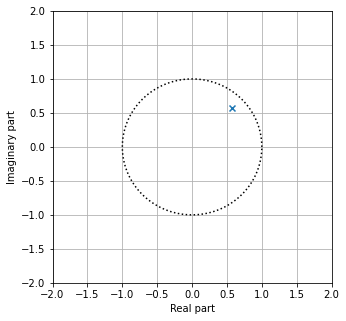

In [60]:
rho = 0.8
phi = np.pi / 4.0

plt.figure(figsize=(5, 5))
plt.scatter(rho * np.cos(phi), rho * np.sin(phi),
                label="poles, k="+str(k), marker="x")

theta = np.linspace(0, 2*np.pi, 360)
plt.plot(np.cos(theta), np.sin(theta), c="black", linestyle="dotted")
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.xlabel("Real part")
plt.ylabel("Imaginary part")
#plt.legend()
plt.grid()
plt.show()

## (3) くし形フィルタ $H(z)=\frac{1-z^{-N}}{1-az^{-N}}$

### (a) 極と零点

\begin{align*}
H(z) &= \frac{z^{N}-1}{z^{N}-a}
\end{align*}
と変形できるので，分子多項式の根から
零点は$z_k=e^{j\frac{2\pi}{N} k}, k=0,1,2,\ldots,N-1$，
極は分母多項式の根から$p_k=ae^{j\frac{2\pi}{N} k}, k=0,1,2,\ldots,N-1$

### (c) 周波数応答

\begin{align*}
H(e^{j\omega}) &= \frac{1-e^{-j\omega N}}{1-ae^{-j\omega N}}
\end{align*}

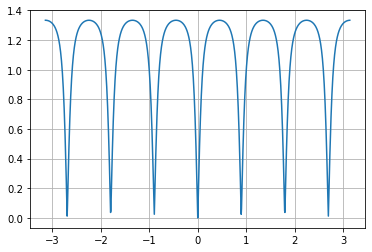

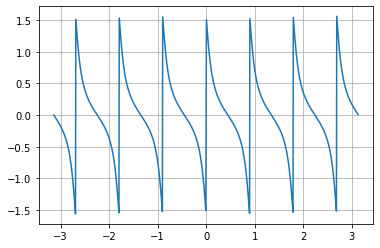

In [75]:
omega = np.linspace(-np.pi, np.pi, 1024, endpoint=False)

rho = 0.5
b = [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0]
a = [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -rho]
_, H = signal.freqz(b, a, omega)
absH = np.abs(H)
argH = np.angle(H)

fig1 = plt.figure()
ax1 = fig1.add_subplot(1, 1, 1)
ax1.plot(omega, absH)
ax1.grid()

fig2 = plt.figure()
ax2 = fig2.add_subplot(1, 1, 1)
ax2.plot(omega, argH)
ax2.grid()

## (4) $H(z)=\frac{a_1+z^{-1}}{1+a_1z^{-1}},\quad |a_1|<1$について

### (a) 全域フィルタであることを示せ．

係数を複素数とすると必ずしも全域フィルタとならなかったので，実数と仮定する．

\begin{align}
|H(e^{j\omega})|^2 &= \frac{a_1+e^{-j\omega}}{1+a_1e^{-j\omega}}\frac{a_1+e^{j\omega}}{1+a_1e^{j\omega}}\\
&= \frac{1 + a_1^2 + a_1(e^{j\omega} + e^{-j\omega})}{1 + a_1^2 + a_1(e^{j\omega} + e^{-j\omega})}\\
&= \frac{1 + a_1^2 + 2a_1\cos \omega}{1 + a_1^2 + 2a_1\cos \omega}\\
&= 1
\end{align}

よって，$|H(e^{j\omega})|=1$

### (b) 極と零点

極:$-a_1$，零点：$-a_1^{-1}$

極と零点の積が1になる．

### (c) $H(z)=\frac{a_2+a_1z^{-1}+z^{-2}}{1+a_1z^{-1}+a_2z^{-2}}$

\begin{align}
|H(e^{j\omega})|^2
&= \frac{a_2+a_1e^{-j\omega}+e^{-j2\omega}}{1+a_1e^{-j\omega}+a_2e^{-j2\omega}}
\frac{a_2+a_1e^{j\omega}+e^{j2\omega}}{1+a_1e^{j\omega}+a_2e^{j2\omega}}\\
&=\frac{1+a_1^2+a_2^2+2a_1(a_2-1)\cos{\omega}+2a_2\cos{2\omega}}
{1+a_1^2+a_2^2+2a_1(a_2-1)\cos{\omega}+2a_2\cos{2\omega}}\\
&= 1
\end{align}

極：$\frac{-a_1\pm \sqrt{a_1^2-4a_2}}{2}$

零点：$\frac{-a_1\pm \sqrt{a_1^2-4a_2}}{2a_2}$